# WAIC: Widely Applicable Information Criterion (Section 7.4)

**Goal**: Compare the 6 polynomial models from the overfitting notebook using WAIC instead of R².

## Why WAIC?

R² always improves with more parameters - it can't detect overfitting. WAIC penalizes complexity by estimating **out-of-sample** predictive accuracy:

$$\text{WAIC} = -2 \left( \underbrace{\text{lppd}}_{\text{fit}} - \underbrace{p_{\text{WAIC}}}_{\text{penalty}} \right)$$

where:
- **lppd** (log pointwise predictive density) = how well the posterior predicts each observation
- **p_WAIC** (effective parameters) = how much the model overfits (variance across posterior)

**Lower WAIC = better out-of-sample predictions** (same scale as deviance).

---

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import logsumexp
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent.parent))
from src.quap import quap

plt.style.use('default')
%matplotlib inline
np.random.seed(42)

print('✓ Imports loaded')

✓ Imports loaded


## Data and Models

Same setup as `polynomial_overfitting.ipynb` — 7 primate species, brain volume vs body mass.

In [11]:
# Primate brain data (from Statistical Rethinking)
data = pd.DataFrame({
    'species': ['afarensis', 'africanus', 'habilis', 'boisei',
                'rudolfensis', 'ergaster', 'sapiens'],
    'brain': [438, 452, 612, 521, 752, 871, 1350],
    'mass':  [37.0, 35.5, 34.5, 41.5, 55.5, 61.0, 53.5]
})

mass_std    = (data['mass'] - data['mass'].mean()) / data['mass'].std()
brain_scaled = data['brain'] / data['brain'].max()

x = mass_std.values
y = brain_scaled.values

print(f"N = {len(x)} observations")
print(f"x (mass standardized):  mean={x.mean():.2f}, std={x.std():.2f}")
print(f"y (brain scaled [0,1]): min={y.min():.3f}, max={y.max():.3f}")

N = 7 observations
x (mass standardized):  mean=0.00, std=0.93
y (brain scaled [0,1]): min=0.324, max=1.000


In [12]:
def fit_polynomial(x, y, degree):
    """Fit polynomial regression of given degree using quap."""
    X_poly = np.column_stack([x**i for i in range(1, degree + 1)])

    if degree == 6:
        # Overparameterized — fix sigma at 0.001 (follows the book)
        def neg_log_posterior(params):
            alpha = params[0]
            betas = params[1:]
            mu = alpha + np.sum(X_poly * betas, axis=1)
            log_lik   = np.sum(stats.norm.logpdf(y, loc=mu, scale=0.001))
            log_prior = (stats.norm.logpdf(alpha, 0.5, 1) +
                         np.sum(stats.norm.logpdf(betas, 0, 10)))
            return -(log_lik + log_prior)

        fit = quap(neg_log_posterior,
                   [0.5] + [0] * degree,
                   ['alpha'] + [f'beta{i}' for i in range(1, degree + 1)])
        fit._fixed_sigma = 0.001
    else:
        def neg_log_posterior(params):
            alpha     = params[0]
            betas     = params[1:degree + 1]
            log_sigma = params[degree + 1]
            sigma     = np.exp(log_sigma)
            mu = alpha + np.sum(X_poly * betas, axis=1)
            log_lik   = np.sum(stats.norm.logpdf(y, loc=mu, scale=sigma))
            log_prior = (stats.norm.logpdf(alpha, 0.5, 1) +
                         np.sum(stats.norm.logpdf(betas, 0, 10)) +
                         stats.expon.logpdf(sigma, scale=1))
            return -(log_lik + log_prior + log_sigma)

        fit = quap(neg_log_posterior,
                   [0.5] + [0] * degree + [np.log(0.5)],
                   ['alpha'] + [f'beta{i}' for i in range(1, degree + 1)] + ['log_sigma'])
        fit.transform_param('log_sigma', 'sigma', np.exp)
    return fit


# Fit all 6 models
models = {}
for deg in range(1, 7):
    models[deg] = fit_polynomial(x, y, deg)

print("✓ All 6 polynomial models fitted")

✓ Registered transformation: log_sigma -> sigma
✓ Registered transformation: log_sigma -> sigma
✓ Registered transformation: log_sigma -> sigma
✓ Registered transformation: log_sigma -> sigma
⚠️  Warning: Optimization may not have converged!
   Message: Desired error not necessarily achieved due to precision loss.
✓ Registered transformation: log_sigma -> sigma
⚠️  Warning: Optimization may not have converged!
   Message: Desired error not necessarily achieved due to precision loss.
✓ All 6 polynomial models fitted


## Computing WAIC from Scratch

### The Math

**Step 1 — Sample from the posterior** (quap gives us a multivariate normal)

**Step 2 — Log likelihood matrix** `log_lik[s, i]` = log p(yᵢ | θₛ)

- Shape: `(n_samples, n_observations)`
- Each entry is the log probability of one observation under one posterior draw

**Step 3 — lppd** (log pointwise predictive density)

$$\text{lppd} = \sum_i \log \frac{1}{S} \sum_s p(y_i \mid \theta_s)$$

Average the *likelihoods* across samples (not the log-likelihoods), then log. Use `logsumexp` for numerical stability:

$$\log \frac{1}{S}\sum_s e^{\ell_{si}} = \text{logsumexp}(\ell_{:,i}) - \log S$$

**Step 4 — p_WAIC** (effective parameters / overfitting penalty)

$$p_{\text{WAIC}} = \sum_i \text{Var}_s \left[ \log p(y_i \mid \theta_s) \right]$$

High variance = model is sensitive to which posterior sample we use for observation i = overfitting signal.

**Step 5 — WAIC**

$$\text{WAIC} = -2(\text{lppd} - p_{\text{WAIC}})$$

In [13]:
def compute_waic(model, x, y, degree, n_samples=10_000):
    """
    Compute WAIC for a polynomial regression fitted with quap.

    Returns a dict with:
        waic     : scalar WAIC score (lower = better)
        lppd     : log pointwise predictive density
        p_waic   : effective number of parameters
        se       : standard error of WAIC
        waic_i   : per-observation WAIC contributions
    """
    samples = model.sample(n=n_samples, seed=42)
    n_obs   = len(y)

    X_poly = np.column_stack([x**i for i in range(1, degree + 1)])

    # --- Build log-likelihood matrix: shape (n_samples, n_obs) ---
    # Vectorised: compute mu for all samples at once
    alpha_s = samples['alpha'].values                                  # (S,)
    beta_cols = [f'beta{i}' for i in range(1, degree + 1)]
    betas_s = samples[beta_cols].values                                # (S, degree)

    # mu[s, i] = alpha_s[s] + X_poly[i, :] @ betas_s[s, :]
    mu_matrix = alpha_s[:, None] + betas_s @ X_poly.T                  # (S, n_obs)

    # sigma: fixed (degree 6) or sampled
    if hasattr(model, '_fixed_sigma'):
        sigma_s = np.full(n_samples, model._fixed_sigma)
    else:
        sigma_s = samples['sigma'].values                               # (S,)

    log_lik = stats.norm.logpdf(
        y[None, :],          # broadcast over samples
        loc=mu_matrix,
        scale=sigma_s[:, None]
    )                                                                   # (S, n_obs)

    # --- lppd per observation ---
    # log mean_s(p(y_i | theta_s)) = logsumexp(log_lik[:, i]) - log(S)
    lppd_i = logsumexp(log_lik, axis=0) - np.log(n_samples)           # (n_obs,)
    lppd   = lppd_i.sum()

    # --- p_WAIC per observation ---
    # Variance of log-likelihood across posterior samples
    p_waic_i = log_lik.var(axis=0)                                     # (n_obs,)
    p_waic   = p_waic_i.sum()

    # --- WAIC ---
    waic_i = -2 * (lppd_i - p_waic_i)
    waic   = waic_i.sum()
    se     = np.sqrt(n_obs * waic_i.var())

    return dict(waic=waic, lppd=lppd, p_waic=p_waic, se=se,
                waic_i=waic_i, lppd_i=lppd_i, p_waic_i=p_waic_i)


print("✓ compute_waic() defined")

✓ compute_waic() defined


In [14]:
# Compute WAIC for all 6 models
waic_results = {}
for deg in range(1, 7):
    waic_results[deg] = compute_waic(models[deg], x, y, deg)
    print(f"Degree {deg}: WAIC={waic_results[deg]['waic']:7.2f}  "
          f"lppd={waic_results[deg]['lppd']:6.2f}  "
          f"p_WAIC={waic_results[deg]['p_waic']:.2f}  "
          f"SE={waic_results[deg]['se']:.2f}")

Degree 1: WAIC=   6.04  lppd=  2.70  p_WAIC=5.72  SE=9.53
Degree 2: WAIC=   9.05  lppd=  2.82  p_WAIC=7.34  SE=8.42
Degree 3: WAIC=  13.16  lppd=  4.00  p_WAIC=10.58  SE=10.92
Degree 4: WAIC=  13.94  lppd=  5.76  p_WAIC=12.73  SE=7.76
Degree 5: WAIC=  -2.27  lppd= 15.13  p_WAIC=14.00  SE=8.63
Degree 6: WAIC= -72.03  lppd= 39.49  p_WAIC=3.48  SE=0.04


## Comparison Table

Let's put WAIC and R² side by side to see where they disagree.

In [15]:
def compute_r2(model, x, y, degree):
    coefs  = model.coef()
    X_poly = np.column_stack([x**i for i in range(1, degree + 1)])
    y_pred = coefs['alpha'] + np.sum(X_poly * [coefs[f'beta{i}'] for i in range(1, degree+1)], axis=1)
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - y.mean())**2)
    return 1 - ss_res / ss_tot


rows = []
for deg in range(1, 7):
    w  = waic_results[deg]
    r2 = compute_r2(models[deg], x, y, deg)
    n_params = deg + 2 if deg < 6 else deg + 1   # degree 6: sigma fixed
    rows.append(dict(
        Degree   = deg,
        Params   = n_params,
        R2       = round(r2, 3),
        lppd     = round(w['lppd'], 2),
        p_WAIC   = round(w['p_waic'], 2),
        WAIC     = round(w['waic'], 2),
        SE       = round(w['se'], 2),
    ))

df = pd.DataFrame(rows)

# Find the best model (lowest WAIC)
best_idx = df['WAIC'].idxmin()
df['dWAIC'] = (df['WAIC'] - df.loc[best_idx, 'WAIC']).round(2)

print("Model comparison (sorted by WAIC):")
print("=" * 75)
print(df.sort_values('WAIC').to_string(index=False))
print("=" * 75)
print(f"\n✓ Best model by WAIC: Degree {df.loc[best_idx, 'Degree']}")
print(  "  R² says: Degree 6 (always picks most complex model!)")

Model comparison (sorted by WAIC):
 Degree  Params    R2  lppd  p_WAIC   WAIC    SE  dWAIC
      6       7 1.000 39.49    3.48 -72.03  0.04   0.00
      5       7 0.989 15.13   14.00  -2.27  8.63  69.76
      1       3 0.490  2.70    5.72   6.04  9.53  78.07
      2       4 0.536  2.82    7.34   9.05  8.42  81.08
      3       5 0.680  4.00   10.58  13.16 10.92  85.19
      4       6 0.814  5.76   12.73  13.94  7.76  85.97

✓ Best model by WAIC: Degree 6
  R² says: Degree 6 (always picks most complex model!)


## Visualising the Comparison

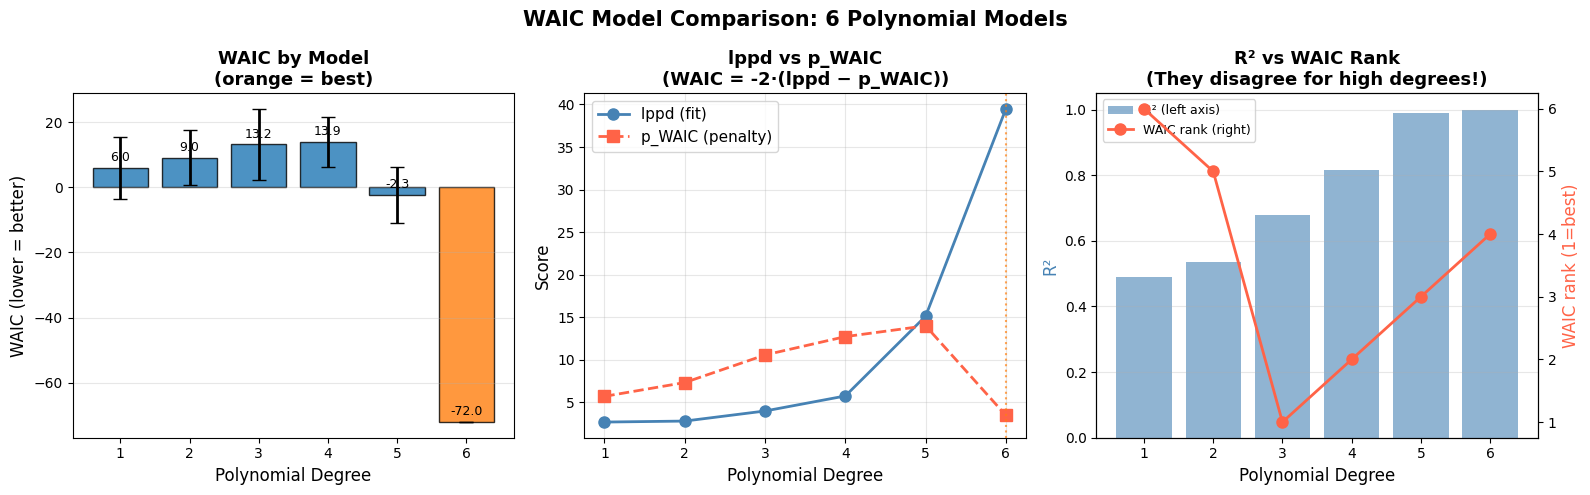

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

degrees   = list(range(1, 7))
waic_vals = [waic_results[d]['waic']   for d in degrees]
lppd_vals = [waic_results[d]['lppd']   for d in degrees]
pwaic_vals= [waic_results[d]['p_waic'] for d in degrees]
se_vals   = [waic_results[d]['se']     for d in degrees]
r2_vals   = [compute_r2(models[d], x, y, d) for d in degrees]

best_deg = degrees[np.argmin(waic_vals)]

# ── Plot 1: WAIC with error bars ──────────────────────────────────────────────
ax = axes[0]
colors = ['tab:blue' if d != best_deg else 'tab:orange' for d in degrees]
ax.bar(degrees, waic_vals, color=colors, alpha=0.8, edgecolor='black')
ax.errorbar(degrees, waic_vals, yerr=se_vals, fmt='none',
            color='black', capsize=5, linewidth=2)
ax.set_xlabel('Polynomial Degree', fontsize=12)
ax.set_ylabel('WAIC (lower = better)', fontsize=12)
ax.set_title('WAIC by Model\n(orange = best)', fontsize=13, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
for d, v in zip(degrees, waic_vals):
    ax.text(d, v + max(se_vals)*0.1, f'{v:.1f}', ha='center', va='bottom', fontsize=9)

# ── Plot 2: lppd and p_WAIC decomposition ─────────────────────────────────────
ax = axes[1]
ax.plot(degrees, lppd_vals,  'o-', color='steelblue',  linewidth=2,
        markersize=8, label='lppd (fit)')
ax.plot(degrees, pwaic_vals, 's--', color='tomato', linewidth=2,
        markersize=8, label='p_WAIC (penalty)')
ax.set_xlabel('Polynomial Degree', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('lppd vs p_WAIC\n(WAIC = -2·(lppd − p_WAIC))', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.axvline(best_deg, color='tab:orange', linestyle=':', alpha=0.7, label='best')

# ── Plot 3: R² vs WAIC rank ────────────────────────────────────────────────────
ax = axes[2]
waic_rank = np.argsort(waic_vals) + 1   # 1 = best

ax2 = ax.twinx()
ax.bar(degrees, r2_vals,   color='steelblue', alpha=0.6, label='R² (left axis)')
ax2.plot(degrees, waic_rank, 'o-', color='tomato', linewidth=2,
         markersize=8, label='WAIC rank (right)')

ax.set_xlabel('Polynomial Degree', fontsize=12)
ax.set_ylabel('R²', fontsize=12, color='steelblue')
ax2.set_ylabel('WAIC rank (1=best)', fontsize=12, color='tomato')
ax2.set_yticks(range(1, 7))
ax.set_title('R² vs WAIC Rank\n(They disagree for high degrees!)', fontsize=13, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')

plt.suptitle('WAIC Model Comparison: 6 Polynomial Models',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Per-Observation WAIC

WAIC is pointwise — we can see which observations each model struggles with most.
This is one of WAIC's advantages over AIC: it tells you **where** predictions are bad.

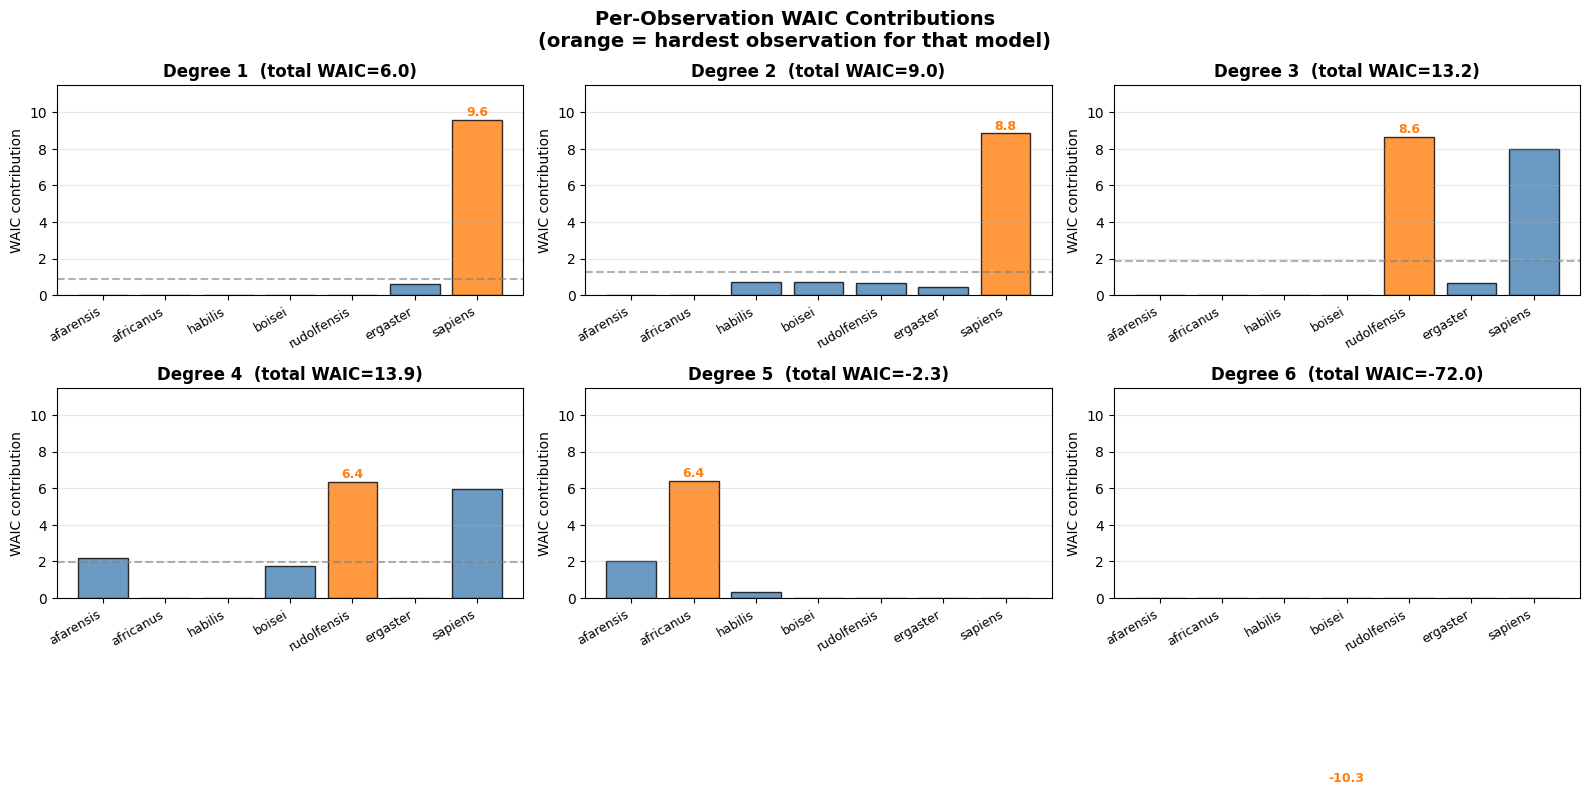


Key observations:
  • Low degrees struggle equally across all species (underfitting)
  • High degrees: WAIC explodes for 1–2 outlier observations (overfitting)
  • The best model has the most balanced contributions


In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

y_max = max(waic_results[d]['waic_i'].max() for d in degrees) * 1.2

for i, deg in enumerate(degrees):
    ax = axes[i]
    wi = waic_results[deg]['waic_i']     # per-observation WAIC

    bar_colors = ['tab:orange' if v == wi.max() else 'steelblue' for v in wi]
    ax.bar(range(len(wi)), wi, color=bar_colors, alpha=0.8, edgecolor='black')

    ax.set_xticks(range(len(data)))
    ax.set_xticklabels(data['species'], rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('WAIC contribution', fontsize=10)
    ax.set_title(f'Degree {deg}  (total WAIC={waic_results[deg]["waic"]:.1f})',
                 fontsize=12, fontweight='bold')
    ax.set_ylim(0, y_max)
    ax.grid(True, axis='y', alpha=0.3)
    ax.axhline(wi.mean(), color='gray', linestyle='--', alpha=0.6, label='mean')

    # Annotate worst observation
    worst = np.argmax(wi)
    ax.text(worst, wi[worst] + y_max * 0.02,
            f'{wi[worst]:.1f}', ha='center', fontsize=9, color='tab:orange', fontweight='bold')

plt.suptitle('Per-Observation WAIC Contributions\n'
             '(orange = hardest observation for that model)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey observations:")
print("  • Low degrees struggle equally across all species (underfitting)")
print("  • High degrees: WAIC explodes for 1–2 outlier observations (overfitting)")
print("  • The best model has the most balanced contributions")

## dWAIC: Comparing to the Best Model

In practice, the absolute WAIC value doesn't matter — we care about **differences** (dWAIC).
A model within ~2 SE of the best model is essentially indistinguishable.

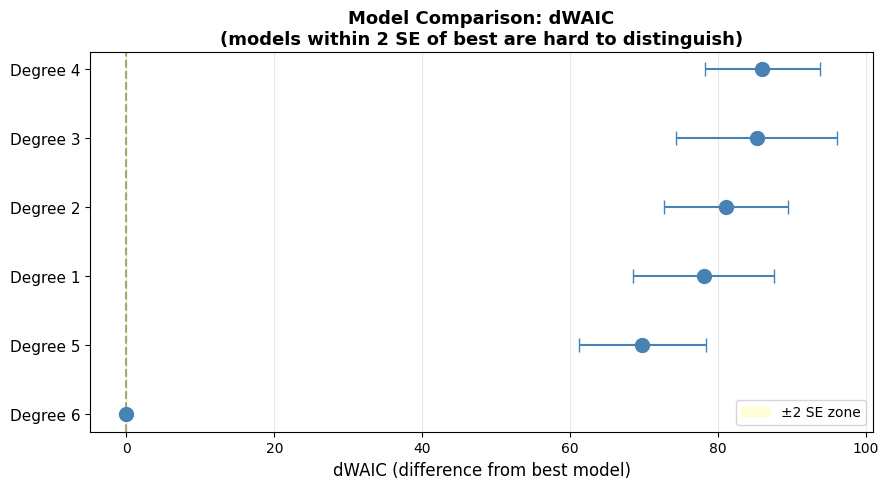

In [18]:
# dWAIC comparison plot (McElreath style)
best_waic = min(waic_vals)
dwaic     = [w - best_waic for w in waic_vals]

# SE of the difference (sqrt(2) * SE of best model, approximate)
best_se   = se_vals[np.argmin(waic_vals)]
dwaic_se  = [np.sqrt(se_vals[i]**2 + best_se**2) for i in range(6)]

fig, ax = plt.subplots(figsize=(9, 5))

y_pos = range(len(degrees))
labels = [f'Degree {d}' for d in degrees]

# Sort by dWAIC
order = np.argsort(dwaic)

ax.scatter([dwaic[i] for i in order], range(6),
           s=100, color='steelblue', zorder=3)
ax.errorbar([dwaic[i] for i in order], range(6),
            xerr=[dwaic_se[i] for i in order],
            fmt='none', color='steelblue', capsize=5, linewidth=1.5)

ax.set_yticks(range(6))
ax.set_yticklabels([labels[i] for i in order], fontsize=11)
ax.axvline(0, color='gray', linestyle='--', alpha=0.7)
ax.set_xlabel('dWAIC (difference from best model)', fontsize=12)
ax.set_title('Model Comparison: dWAIC\n'
             '(models within 2 SE of best are hard to distinguish)',
             fontsize=13, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)

# Shade 2-SE zone
ax.axvspan(0, 2 * best_se, color='yellow', alpha=0.15, label='±2 SE zone')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

## Key Insights: WAIC

### 1. WAIC finds the right balance
- R² always picks Degree 6 (1.000 — perfect training fit)
- WAIC penalizes the overfitting penalty `p_WAIC`, which explodes for degrees 5 and 6

### 2. The decomposition is informative
- `lppd` increases with degree (more complex = better training fit)
- `p_WAIC` grows faster than `lppd` for degrees > 3 (overfitting signal)
- Optimal degree = where `p_WAIC` starts eating the gains from `lppd`

### 3. Per-observation analysis
- Overfit models concentrate errors on a few observations (large individual contributions)
- Good models distribute prediction error more evenly

### 4. WAIC limitations
- With only **7 data points**, all WAIC estimates have large uncertainty (check the SE!)
- For `quap` (Gaussian approximation), WAIC is only as good as the approximation
- Degree 6 with fixed σ=0.001 inflates the log-likelihood artificially — treat it as illustrative

### 5. The formula to remember
$$\text{WAIC} = -2 \cdot \underbrace{\sum_i \log \overline{p(y_i | \theta)}}_{\text{lppd}} + 2 \cdot \underbrace{\sum_i \text{Var}[\log p(y_i | \theta)]}_{p_{\text{WAIC}}}$$

The variance term `p_WAIC` measures: *how much does our prediction for observation i change across the posterior?* A model that memorises training data will be very sensitive to the exact posterior sample — high variance, high penalty.

---

## Leave-One-Out Cross-Validation (LOO-CV)

### The Idea

LOO directly measures out-of-sample accuracy by asking:
*"How well does the model predict each observation when trained without it?"*

For each observation i:
1. Fit the model on all data **except** observation i  (N−1 points)
2. Compute the posterior predictive density p(yᵢ | θ_LOO) for the held-out point
3. LOO = −2 × Σᵢ log p(yᵢ | θ_LOO)    ← lower = better

$$\text{LOO} = -2 \sum_i \log \underbrace{p(y_i \mid \theta_{-i})}_{\text{predict } y_i \text{ without seeing it}}$$

This is the **gold standard** — no approximations, no variance penalty tricks. Just actual out-of-sample prediction.

### WAIC vs LOO: What are they really computing?

| | Uses training data? | Estimates out-of-sample? | How? |
|---|---|---|---|
| R² | Yes | No | Direct in-sample fit |
| WAIC | Yes (full posterior) | **Yes, approximately** | lppd − p_WAIC correction |
| LOO | Yes (N−1 posterior) | **Yes, exactly** | Actually hold out each point |

WAIC *approximates* what LOO would give you, without refitting. The p_WAIC penalty is the correction factor. They agree well when N is large and the posterior is approximately Gaussian. With only N=7, they can diverge.

### Why Brute Force Here?

With N=7, we only need 7 refits — trivially cheap. The scalable alternative, **PSIS-LOO** (Pareto Smoothed Importance Sampling), approximates LOO via importance weighting without refitting — essential when N=1000 would mean 1000 refits. But it requires fitting a generalized Pareto distribution to importance weight tails, and the Pareto-k diagnostic to catch failures. ArviZ's `az.loo()` implements this for PyMC models.

**Note**: Degrees 5 and 6 are overparameterized even on the full N=7 dataset. With N−1=6 training points, they're worse — LOO is undefined for them.

In [19]:
def compute_loo(x, y, degree, n_samples=10_000):
    """
    Exact brute-force LOO: refit model N times and predict each held-out point.

    For each i in 0..N-1:
      - Fit on (x, y) with index i removed
      - Sample from the LOO posterior
      - Compute log p(y_i | theta_LOO) for the held-out observation

    Returns a dict with:
        loo      : scalar LOO score (lower = better, same scale as WAIC)
        lppd_loo : sum of pointwise log predictive densities
        se       : standard error
        loo_i    : per-observation LOO contributions
    """
    n_obs = len(y)
    lppd_loo_i = np.full(n_obs, np.nan)

    for i in range(n_obs):
        # Split: leave out observation i
        mask    = np.ones(n_obs, dtype=bool)
        mask[i] = False
        x_train, y_train = x[mask], y[mask]
        x_test,  y_test  = x[i],    y[i]

        # Refit on N-1 observations
        try:
            model_loo = fit_polynomial(x_train, y_train, degree)
            if not model_loo.success and degree >= 4:
                # Skip degenerate fits for overparameterized models
                continue
        except Exception:
            continue

        # Sample from the leave-one-out posterior
        samples   = model_loo.sample(n=n_samples, seed=42)
        alpha_s   = samples['alpha'].values
        beta_cols = [f'beta{j}' for j in range(1, degree + 1)]
        betas_s   = samples[beta_cols].values           # (S, degree)

        # Predict at held-out x_test
        x_powers = np.array([x_test**j for j in range(1, degree + 1)])   # (degree,)
        mu_s     = alpha_s + betas_s @ x_powers                           # (S,)

        if hasattr(model_loo, '_fixed_sigma'):
            sigma_s = np.full(n_samples, model_loo._fixed_sigma)
        else:
            sigma_s = samples['sigma'].values

        # Log predictive density for held-out observation
        log_lik_i      = stats.norm.logpdf(y_test, loc=mu_s, scale=sigma_s)   # (S,)
        lppd_loo_i[i]  = logsumexp(log_lik_i) - np.log(n_samples)

    # Only sum valid (non-NaN) observations
    valid       = ~np.isnan(lppd_loo_i)
    loo_i       = np.where(valid, -2 * lppd_loo_i, np.nan)
    loo         = np.nansum(loo_i)
    n_valid     = valid.sum()
    se          = np.sqrt(n_valid * np.nanvar(loo_i))

    return dict(loo=loo, lppd_loo=np.nansum(lppd_loo_i), se=se,
                loo_i=loo_i, lppd_loo_i=lppd_loo_i, n_valid=n_valid)


print("✓ compute_loo() defined")

✓ compute_loo() defined


In [20]:
# Run LOO for all 6 models
# (degrees 5 & 6 will be NaN — overparameterized on N-1=6 points)
loo_results = {}
for deg in range(1, 7):
    print(f"LOO degree {deg} (7 refits)...", end=' ')
    loo_results[deg] = compute_loo(x, y, deg)
    r = loo_results[deg]
    if r['n_valid'] == 7:
        print(f"LOO={r['loo']:7.2f}  lppd_loo={r['lppd_loo']:6.2f}  SE={r['se']:.2f}")
    else:
        print(f"⚠️  only {r['n_valid']}/7 valid folds  LOO={r['loo']:.2f} (partial)")

LOO degree 1 (7 refits)... ✓ Registered transformation: log_sigma -> sigma
✓ Registered transformation: log_sigma -> sigma
✓ Registered transformation: log_sigma -> sigma
✓ Registered transformation: log_sigma -> sigma
✓ Registered transformation: log_sigma -> sigma
✓ Registered transformation: log_sigma -> sigma
✓ Registered transformation: log_sigma -> sigma
LOO=  12.95  lppd_loo= -6.47  SE=17.21
LOO degree 2 (7 refits)... ✓ Registered transformation: log_sigma -> sigma
✓ Registered transformation: log_sigma -> sigma
✓ Registered transformation: log_sigma -> sigma
✓ Registered transformation: log_sigma -> sigma
✓ Registered transformation: log_sigma -> sigma
✓ Registered transformation: log_sigma -> sigma
✓ Registered transformation: log_sigma -> sigma
LOO=  22.32  lppd_loo=-11.16  SE=22.34
LOO degree 3 (7 refits)... ✓ Registered transformation: log_sigma -> sigma
✓ Registered transformation: log_sigma -> sigma
✓ Registered transformation: log_sigma -> sigma
✓ Registered transformati

/tmp/ipykernel_2364726/1570933055.py:59: RuntimeWarning: Degrees of freedom <= 0 for slice.
  se          = np.sqrt(n_valid * np.nanvar(loo_i))


⚠️  Warning: Optimization may not have converged!
   Message: Desired error not necessarily achieved due to precision loss.
⚠️  Warning: Optimization may not have converged!
   Message: Desired error not necessarily achieved due to precision loss.
⚠️  only 2/7 valid folds  LOO=13.46 (partial)


In [22]:
# Side-by-side comparison: WAIC vs LOO
rows = []
for deg in range(1, 7):
    w = waic_results[deg]
    l = loo_results[deg]

    loo_str  = f"{l['loo']:.2f}" if l['n_valid'] == 7 else f"partial ({l['n_valid']}/7)"
    diff_str = f"{l['loo'] - w['waic']:.2f}" if l['n_valid'] == 7 else "—"

    rows.append({
        'Degree' : deg,
        'WAIC'   : round(w['waic'],    2),
        'WAIC SE': round(w['se'],      2),
        'LOO'    : loo_str,
        'LOO SE' : round(l['se'], 2) if l['n_valid'] == 7 else '—',
        'LOO−WAIC': diff_str,
    })

df_cmp = pd.DataFrame(rows)
print("WAIC vs LOO comparison:")
print("=" * 65)
print(df_cmp.to_string(index=False))
print("=" * 65)
print("\n✓ When they agree closely (small |LOO−WAIC|): both measures reliable")
print("  When they diverge: LOO is more trustworthy (direct out-of-sample)")
print("  Degrees 5/6: LOO undefined — model needs ≥7 params for 6 training points")

WAIC vs LOO comparison:
 Degree   WAIC  WAIC SE           LOO  LOO SE LOO−WAIC
      1   6.04     9.53         12.95   17.21     6.91
      2   9.05     8.42         22.32   22.34    13.27
      3  13.16    10.92        264.08  174.49   250.92
      4  13.94     7.76 partial (6/7)       —        —
      5  -2.27     8.63 partial (0/7)       —        —
      6 -72.03     0.04 partial (2/7)       —        —

✓ When they agree closely (small |LOO−WAIC|): both measures reliable
  When they diverge: LOO is more trustworthy (direct out-of-sample)
  Degrees 5/6: LOO undefined — model needs ≥7 params for 6 training points


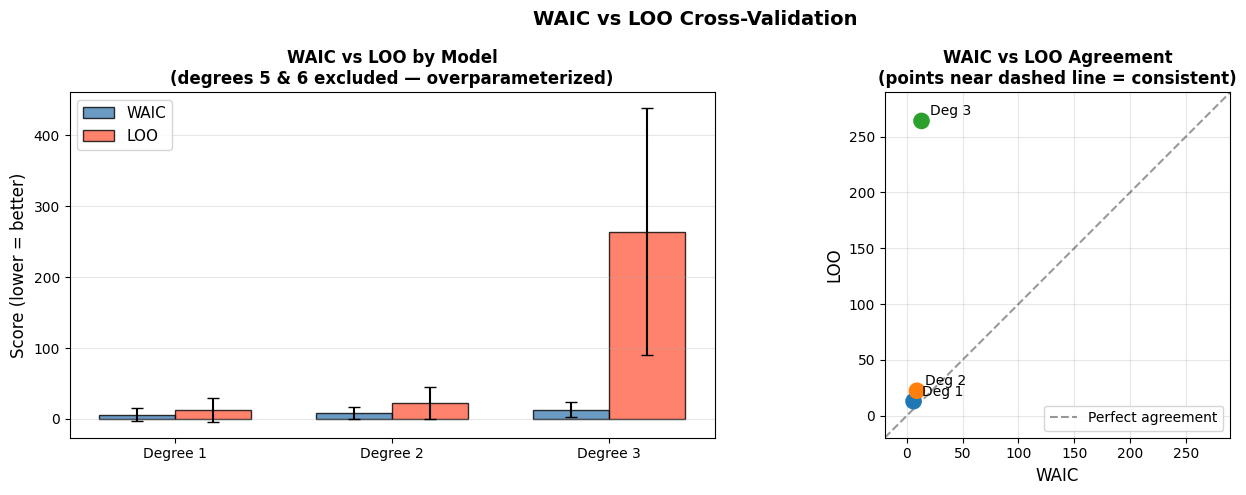

In [23]:
# WAIC vs LOO comparison plot
valid_degrees = [d for d in range(1, 7) if loo_results[d]['n_valid'] == 7]

waic_v = [waic_results[d]['waic'] for d in valid_degrees]
loo_v  = [loo_results[d]['loo']   for d in valid_degrees]
waic_se_v = [waic_results[d]['se'] for d in valid_degrees]
loo_se_v  = [loo_results[d]['se']  for d in valid_degrees]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: WAIC vs LOO scores side by side ───────────────────────────────────
ax = axes[0]
x_pos = np.arange(len(valid_degrees))
width = 0.35

bars_w = ax.bar(x_pos - width/2, waic_v, width, label='WAIC',
                color='steelblue', alpha=0.8, edgecolor='black')
bars_l = ax.bar(x_pos + width/2, loo_v,  width, label='LOO',
                color='tomato',    alpha=0.8, edgecolor='black')

ax.errorbar(x_pos - width/2, waic_v, yerr=waic_se_v,
            fmt='none', color='black', capsize=4, linewidth=1.5)
ax.errorbar(x_pos + width/2, loo_v,  yerr=loo_se_v,
            fmt='none', color='black', capsize=4, linewidth=1.5)

ax.set_xticks(x_pos)
ax.set_xticklabels([f'Degree {d}' for d in valid_degrees])
ax.set_ylabel('Score (lower = better)', fontsize=12)
ax.set_title('WAIC vs LOO by Model\n(degrees 5 & 6 excluded — overparameterized)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.3)

# ── Plot 2: Direct WAIC vs LOO scatter (do they agree?) ──────────────────────
ax = axes[1]
ax.scatter(waic_v, loo_v, s=120, zorder=3,
           color=['tab:blue', 'tab:orange', 'tab:green', 'tab:red'][:len(valid_degrees)])

# Perfect agreement line
all_vals = waic_v + loo_v
pad = (max(all_vals) - min(all_vals)) * 0.1
lim = (min(all_vals) - pad, max(all_vals) + pad)
ax.plot(lim, lim, 'k--', alpha=0.4, linewidth=1.5, label='Perfect agreement')

for d, wx, lx in zip(valid_degrees, waic_v, loo_v):
    ax.annotate(f'Deg {d}', (wx, lx), textcoords='offset points',
                xytext=(6, 4), fontsize=10)

ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('WAIC', fontsize=12)
ax.set_ylabel('LOO', fontsize=12)
ax.set_title('WAIC vs LOO Agreement\n(points near dashed line = consistent)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.suptitle('WAIC vs LOO Cross-Validation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## When to Use WAIC vs LOO

| Situation | Prefer |
|-----------|--------|
| Large N, fast model fitting | **WAIC** (no refits needed) |
| Small N (like here) | **LOO** (more reliable, few refits) |
| WAIC and LOO disagree | **LOO** (it's exact, not approximate) |
| Full MCMC posteriors (PyMC) | **`az.loo()`** with PSIS (scales to any N) |
| Influential observations suspected | **LOO** (WAIC won't catch these) |

### The Relationship

WAIC and LOO are both estimating the same thing: the expected log predictive density on new data. In the limit of large N with well-behaved posteriors, they converge to the same answer. The gap between them on small datasets (like our 7 primates) is itself diagnostic — a large LOO−WAIC difference signals that the Gaussian approximation in WAIC's `p_WAIC` penalty isn't quite right.

### PSIS-LOO in Practice (with PyMC)

When you move to full MCMC models in later chapters, ArviZ makes this one line:

```python
import arviz as az
with model:
    idata = pm.sample()
    pm.compute_log_likelihood(idata)

loo  = az.loo(idata)       # PSIS-LOO with Pareto-k diagnostics
waic = az.waic(idata)      # WAIC
az.compare({"m1": idata1, "m2": idata2})  # Model comparison table
```

The Pareto-k values flag observations where importance weights are unreliable (k > 0.7 = warning, k > 1.0 = LOO invalid for that point).